# TASK 1: Data Collection & Dataset Understanding

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('raw_sales.csv')
df = pd.DataFrame(data)

In [4]:
print("=== TASK 1: Dataset Understanding ===")
print(f"Dataset Shape: {df.shape[0]:,} rows and {df.shape[1]} columns")

print("\nColumns and Data Types:")
display(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing Values:")
display(df.isnull().sum())

print("\nBasic Statistics:")
display(df.describe(include='all'))

# Understanding the data
print("\nUnique Values:")
print("Property Types:", df['propertyType'].unique())
print("Bedrooms:", sorted(df['bedrooms'].unique()))
print("Unique Postcodes:", df['postcode'].nunique())

=== TASK 1: Dataset Understanding ===
Dataset Shape: 29,580 rows and 5 columns

Columns and Data Types:


datesold        object
postcode         int64
price            int64
propertyType    object
bedrooms         int64
dtype: object


First 5 rows:


,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3



Missing Values:


datesold        0
postcode        0
price           0
propertyType    0
bedrooms        0
dtype: int64


Basic Statistics:


,datesold,postcode,price,propertyType,bedrooms
count,29580,29580.000000,2.958000e+04,29580,29580.000000
unique,3582,NaN,NaN,2,NaN
top,2017-10-28 00:00:00,NaN,NaN,house,NaN
freq,50,NaN,NaN,24552,NaN
mean,NaN,2730.249730,6.097363e+05,NaN,3.250169
std,NaN,146.717292,2.817079e+05,NaN,0.951275
min,NaN,2600.000000,5.650000e+04,NaN,0.000000
25%,NaN,2607.000000,4.400000e+05,NaN,3.000000
50%,NaN,2615.000000,5.500000e+05,NaN,3.000000
75%,NaN,2905.000000,7.050000e+05,NaN,4.000000



Unique Values:
Property Types: ['house' 'unit']
Bedrooms: [0, 1, 2, 3, 4, 5]
Unique Postcodes: 27


# **Dataset Overview and Description**
#### This dataset contains historical property sales in Canberra, Australia (2007–2019).
#### It includes sale date, postcode, price, property type (house/unit), and number of bedrooms.
#### It is useful for analyzing real estate market trends, pricing, and property characteristics.
#### The features include:
* datesold 
* postcode
* price
* propertyType
* bedrooms
#### There are no missing values in each features of the dataset
#### The propertyType feature has two unique values which are:
* house
* unit

# Task 2: Data Cleaning and Preprocessing


In [5]:
# Make a copy for cleaning
df_clean = df.copy()

# 1. Convert datesold to proper datetime
df_clean['datesold'] = pd.to_datetime(df_clean['datesold'])

# 2. Create useful new columns
df_clean['year'] = df_clean['datesold'].dt.year
df_clean['month'] = df_clean['datesold'].dt.month
df_clean['year_month'] = df_clean['datesold'].dt.to_period('M')

# 3. Handle any potential issues (though this dataset is quite clean)
print("Before cleaning:", df.shape)
print("After cleaning shape:", df_clean.shape)

# Check for duplicates
duplicates = df_clean.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()

# Price should be positive
invalid_prices = df_clean[df_clean['price'] <= 0]
print(f"Invalid prices: {len(invalid_prices)}")

# Final check
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

# Save cleaned version
df_clean.to_csv('cleaned_sales.csv', index=False)
print("Cleaned dataset saved as 'cleaned_sales.csv'")

Before cleaning: (29580, 5)
After cleaning shape: (29580, 8)
Duplicate rows: 0
Invalid prices: 0

Missing values after cleaning:
datesold        0
postcode        0
price           0
propertyType    0
bedrooms        0
year            0
month           0
year_month      0
dtype: int64
Cleaned dataset saved as 'cleaned_sales.csv'


# Task 3: Exploratory Data Analysis (EDA)


Overall Price Statistics:


count    2.958000e+04
mean     6.097363e+05
std      2.817079e+05
min      5.650000e+04
25%      4.400000e+05
50%      5.500000e+05
75%      7.050000e+05
max      8.000000e+06
Name: price, dtype: float64


Sales by Property Type:


propertyType
house    24552
unit      5028
Name: count, dtype: int64


Average Price by Property Type:


...


Average Price by Number of Bedrooms:


bedrooms
5    919056.06
4    718171.14
3    552304.43
0    542300.00
2    442222.92
1    335992.91
Name: price, dtype: float64


Yearly Sales Trend:


price                     
     count       mean    median
year                           
2007   147  522377.21  480000.0
2008   639  493814.16  442000.0
2009  1426  496092.03  450000.0
2010  1555  559564.81  510000.0
2011  1633  566715.11  510000.0
2012  1858  552501.37  510000.0
2013  2119  553416.30  520000.0
2014  2863  592653.76  540000.0
2015  3648  626101.34  568000.0
2016  3908  635185.31  575000.0
2017  4541  671880.55  607000.0
2018  3858  660701.04  615000.0
2019  1385  634184.22  600000.0

<Figure size 1500x1000 with 0 Axes>

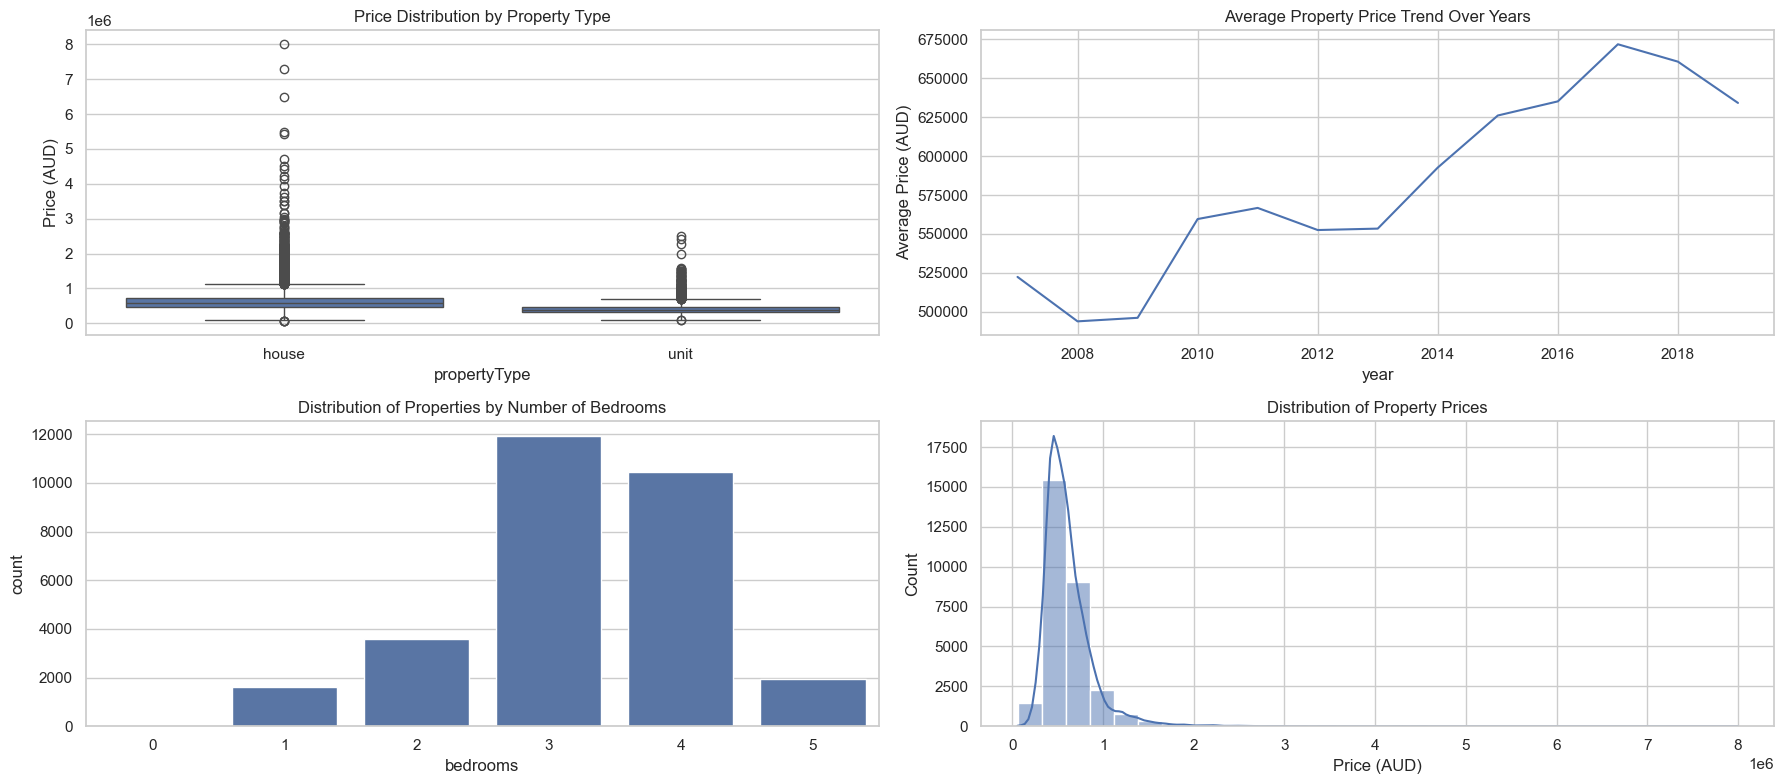

In [7]:
# Set style
sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))

# Basic Statistics
print("\nOverall Price Statistics:")
display(df_clean['price'].describe())

# Sales by Property Type
print("\nSales by Property Type:")
display(df_clean['propertyType'].value_counts())

# Average price by property type and bedrooms
print("\nAverage Price by Property Type:")
display(df_clean.groupby('propertyType')['price'].mean().round(2))

print("\nAverage Price by Number of Bedrooms:")
display(df_clean.groupby('bedrooms')['price'].mean().round(2).sort_values(ascending=False))

# Trend Over Years
yearly_sales = df_clean.groupby('year').agg({
    'price': ['count', 'mean', 'median']
}).round(2)
print("\nYearly Sales Trend:")
display(yearly_sales)

# === Visualizations ===
plt.figure(figsize=(18, 8))
plt.subplot(2, 2, 1)
sns.boxplot(x='propertyType', y='price', data=df_clean)
plt.title('Price Distribution by Property Type')
plt.ylabel('Price (AUD)')

plt.subplot(2, 2, 2)
sns.lineplot(data=yearly_sales['price']['mean'])
plt.title('Average Property Price Trend Over Years')
plt.ylabel('Average Price (AUD)')


plt.subplot(2, 2, 3)
sns.countplot(x='bedrooms', data=df_clean)
plt.title('Distribution of Properties by Number of Bedrooms')

plt.subplot(2, 2, 4)
sns.histplot(df_clean['price'], bins=30, kde=True)
plt.title('Distribution of Property Prices')
plt.xlabel('Price (AUD)')
plt.tight_layout()
plt.show()

## **Key Insights**

- **Project objective:** Analyze sales data to understand pricing patterns, inventory composition, and temporal trends to inform pricing strategy and inventory planning.
- **Data & preparation:** Combined raw and cleaned sales datasets, removed duplicates and invalid entries, normalized price fields, and created `df_clean` for analysis.
- **Approach:** Performed exploratory data analysis, aggregated sales by year and property attributes, inspected distributions, and measured correlations between price and features like bedroom count.
- **Top findings:** Houses command higher average prices than units; prices show an upward trend over time with periodic fluctuations; 3- and 4-bedroom properties are the most common; there is a strong positive correlation between bedroom count and price.
- **Business implications:** Focus marketing and pricing strategies on 3–4 bedroom homes, prioritize inventory acquisition in segments with rising price trends, and adjust pricing models to account for bedroom-count premiums.
- **Limitations & next steps:** Dataset may omit external factors (location-specific demand, renovations). Recommend adding geographic features, expanding time range, and building a predictive pricing model for actionable forecasts.